In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_excel("../data/electricity_data.xlsx")

In [3]:
df.head()

,Family_Members,AC_Count,Fan_Count,Refrigerator_Count,TV_Count,WashingMachine_UsesPerWeek,Daily_Usage_Hours,Previous_Month_Units,Average_Temperature_C,Monthly_Units,Monthly_Bill_INR
0,7,0,7,1,1,2,7,172,41,324,1692
1,6,3,6,1,1,2,13,428,24,589,3812
2,3,3,4,1,2,7,18,123,29,499,3092
3,4,2,5,1,2,1,6,314,27,404,2332
4,8,2,8,1,3,4,13,183,36,506,3148


In [4]:
df.tail()

,Family_Members,AC_Count,Fan_Count,Refrigerator_Count,TV_Count,WashingMachine_UsesPerWeek,Daily_Usage_Hours,Previous_Month_Units,Average_Temperature_C,Monthly_Units,Monthly_Bill_INR
495,5,1,7,1,3,6,18,268,28,481,2948
496,6,0,7,1,1,6,8,434,29,404,2332
497,3,3,4,1,3,6,18,194,39,565,3620
498,2,1,5,1,2,3,8,141,30,307,1556
499,8,2,8,1,2,1,5,452,34,511,3188


In [5]:
df.shape

(500, 11)

In [6]:
df.columns

Index(['Family_Members', 'AC_Count', 'Fan_Count', 'Refrigerator_Count',
       'TV_Count', 'WashingMachine_UsesPerWeek', 'Daily_Usage_Hours',
       'Previous_Month_Units', 'Average_Temperature_C', 'Monthly_Units',
       'Monthly_Bill_INR'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Family_Members              500 non-null    int64
 1   AC_Count                    500 non-null    int64
 2   Fan_Count                   500 non-null    int64
 3   Refrigerator_Count          500 non-null    int64
 4   TV_Count                    500 non-null    int64
 5   WashingMachine_UsesPerWeek  500 non-null    int64
 6   Daily_Usage_Hours           500 non-null    int64
 7   Previous_Month_Units        500 non-null    int64
 8   Average_Temperature_C       500 non-null    int64
 9   Monthly_Units               500 non-null    int64
 10  Monthly_Bill_INR            500 non-null    int64
dtypes: int64(11)
memory usage: 43.1 KB


In [8]:
df.describe()

,Family_Members,AC_Count,Fan_Count,Refrigerator_Count,TV_Count,WashingMachine_UsesPerWeek,Daily_Usage_Hours,Previous_Month_Units,Average_Temperature_C,Monthly_Units,Monthly_Bill_INR
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,5.042000,1.534000,6.104000,1.106000,2.032000,3.844000,11.780000,308.556000,32.82600,467.552000,2841.514000
std,2.060273,1.106025,1.823138,0.308146,0.805154,1.977748,4.039336,105.349855,5.36183,87.819108,700.061336
min,2.000000,0.000000,2.000000,1.000000,1.000000,1.000000,5.000000,120.000000,24.00000,246.000000,1149.000000
25%,3.000000,1.000000,5.000000,1.000000,1.000000,2.000000,8.000000,219.500000,28.00000,405.750000,2346.000000
50%,5.000000,2.000000,7.000000,1.000000,2.000000,4.000000,12.000000,308.000000,32.50000,470.500000,2864.000000
75%,7.000000,2.000000,8.000000,1.000000,3.000000,6.000000,15.000000,403.500000,37.00000,532.000000,3356.000000
max,8.000000,3.000000,8.000000,2.000000,3.000000,7.000000,18.000000,480.000000,42.00000,700.000000,4700.000000


In [9]:
df.isnull().sum()

Family_Members                0
AC_Count                      0
Fan_Count                     0
Refrigerator_Count            0
TV_Count                      0
WashingMachine_UsesPerWeek    0
Daily_Usage_Hours             0
Previous_Month_Units          0
Average_Temperature_C         0
Monthly_Units                 0
Monthly_Bill_INR              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

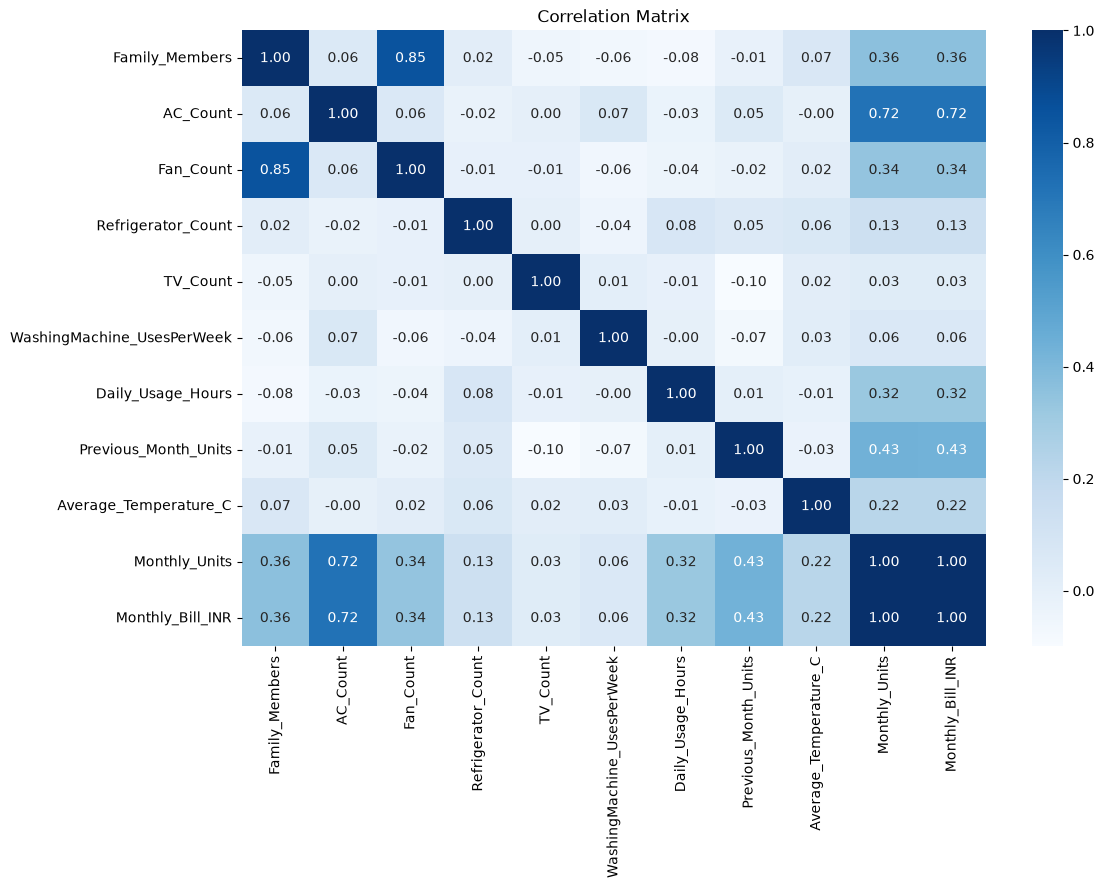

In [11]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

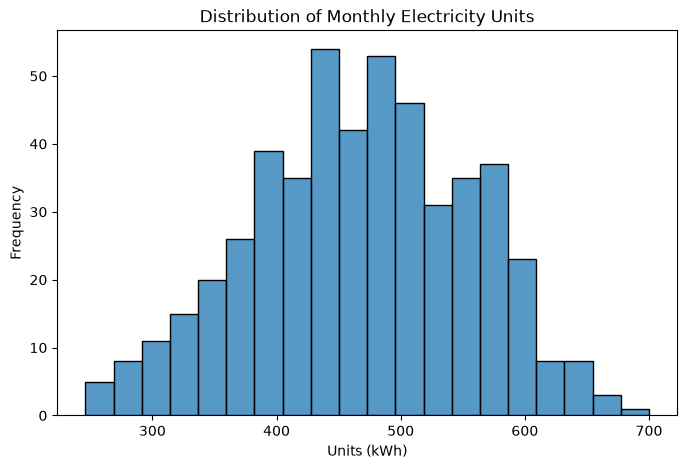

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Monthly_Units"], bins=20)

plt.title("Distribution of Monthly Electricity Units")
plt.xlabel("Units (kWh)")
plt.ylabel("Frequency")

plt.show()

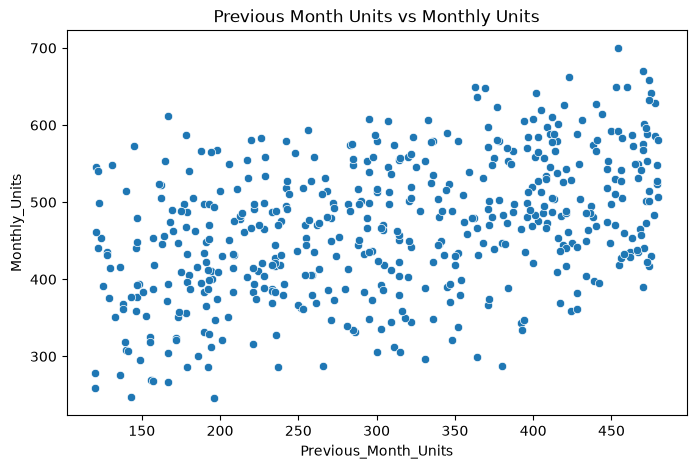

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Previous_Month_Units",
    y="Monthly_Units",
    data=df
)

plt.title("Previous Month Units vs Monthly Units")

plt.show()

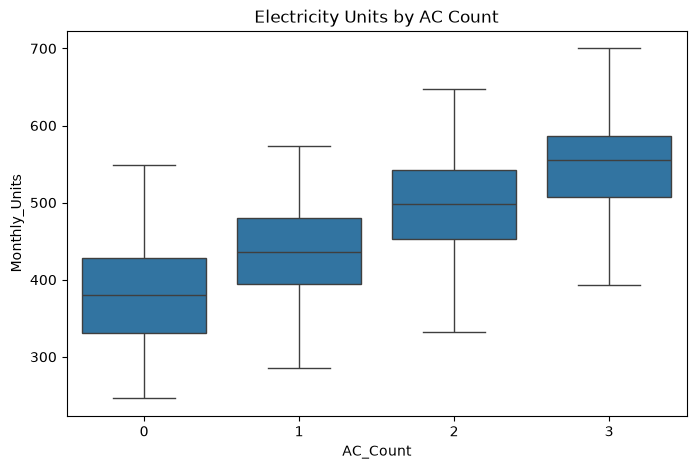

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="AC_Count",
    y="Monthly_Units",
    data=df
)

plt.title("Electricity Units by AC Count")

plt.show()

In [15]:
df.to_csv("../data/cleaned_data.csv", index=False)